In [1]:
# =========================
# Standard Libraries
# =========================
import warnings
import datetime

# =========================
# Data Handling
# =========================
import numpy as np
import pandas as pd

# =========================
# Visualization
# =========================
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Scikit-learn (Preprocessing & Evaluation)
# =========================
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# =========================
# TensorFlow / Keras (Deep Learning)
# =========================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM

In [2]:
data = pd.read_csv('GoogleStock.csv',thousands=',')
data

,Date,Open,High,Low,Close,Volume
0,1/3/2012,325.25,332.83,324.97,663.59,7380500
1,1/4/2012,331.27,333.87,329.08,666.45,5749400
2,1/5/2012,329.83,330.75,326.89,657.21,6590300
3,1/6/2012,328.34,328.77,323.68,648.24,5405900
4,1/9/2012,322.04,322.29,309.46,620.76,11688800
...,...,...,...,...,...,...
1253,12/23/2016,790.90,792.74,787.28,789.91,623400
1254,12/27/2016,790.68,797.86,787.66,791.55,789100
1255,12/28/2016,793.70,794.23,783.20,785.05,1153800
1256,12/29/2016,783.33,785.93,778.92,782.79,744300


Text(0, 0.5, 'Stock Volume')

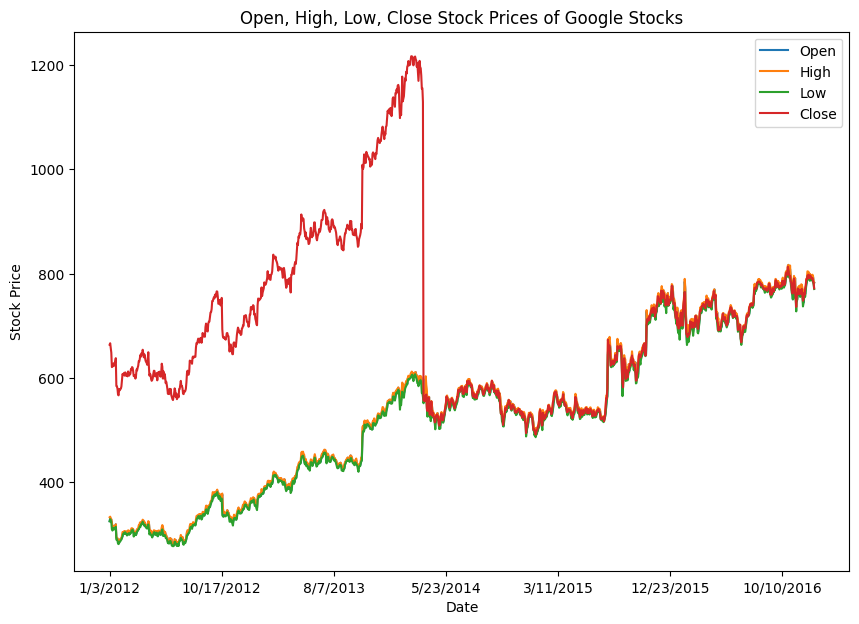

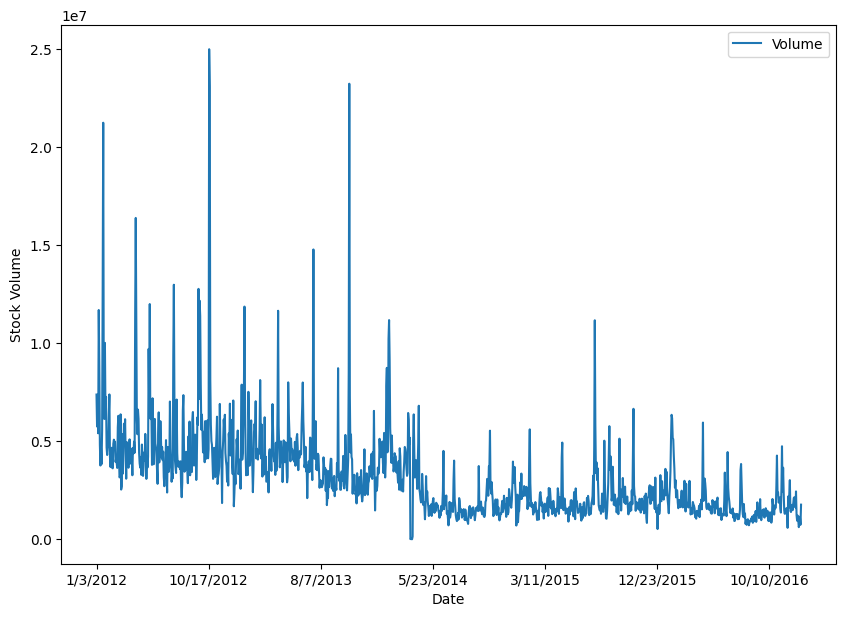

In [3]:
ax1 = data.plot(x="Date", y=["Open", "High", "Low", "Close"], figsize=(10,7),title='Open, High, Low, Close Stock Prices of Google Stocks')
ax1.set_ylabel("Stock Price")

ax2 = data.plot(x="Date", y=["Volume"],  figsize=(10,7))
ax2.set_ylabel("Stock Volume")

In [4]:
data.isna().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

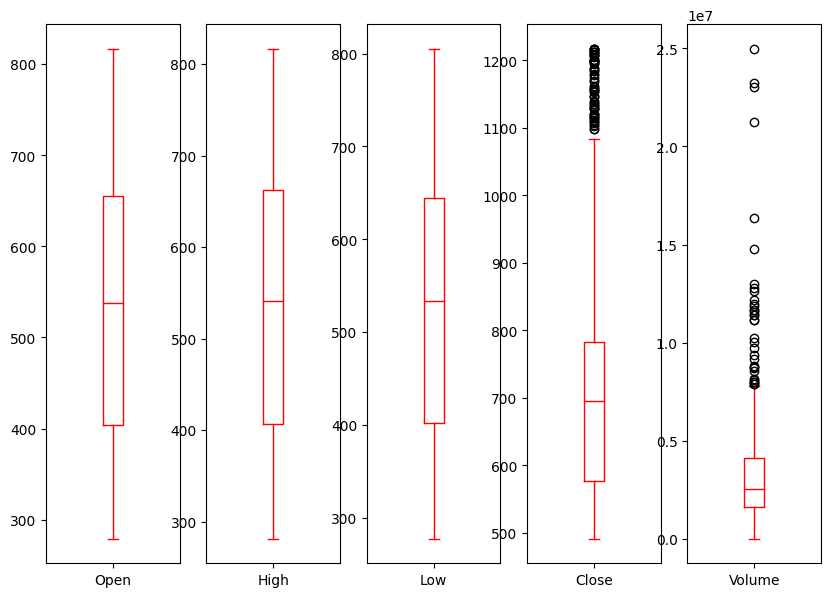

In [5]:
data[['Open','High','Low','Close','Volume']].plot(kind='box', layout=(1,5), subplots=True, sharex=False, sharey=False, figsize=(10,7),color='red')
plt.show()

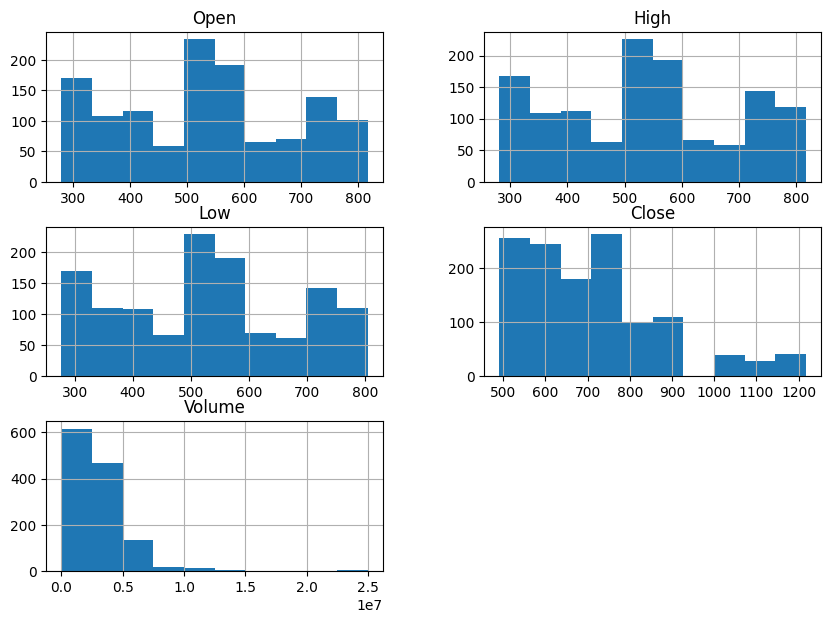

In [6]:
data.hist(figsize=(10,7))
plt.show()

In [7]:
scaler = MinMaxScaler()
data_without_date = data.drop("Date", axis=1)
scaled_data = pd.DataFrame(scaler.fit_transform(data_without_date))

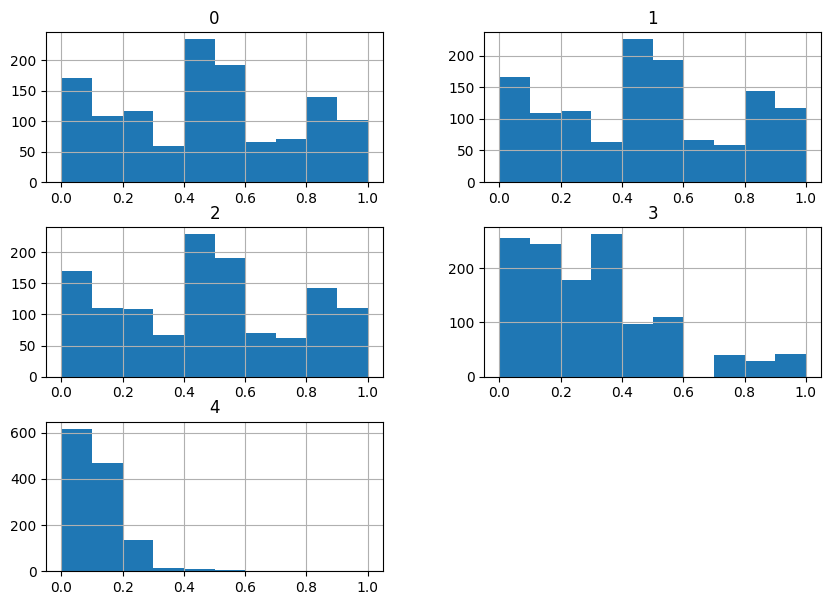

In [8]:
scaled_data.hist(figsize=(10,7))
plt.show()

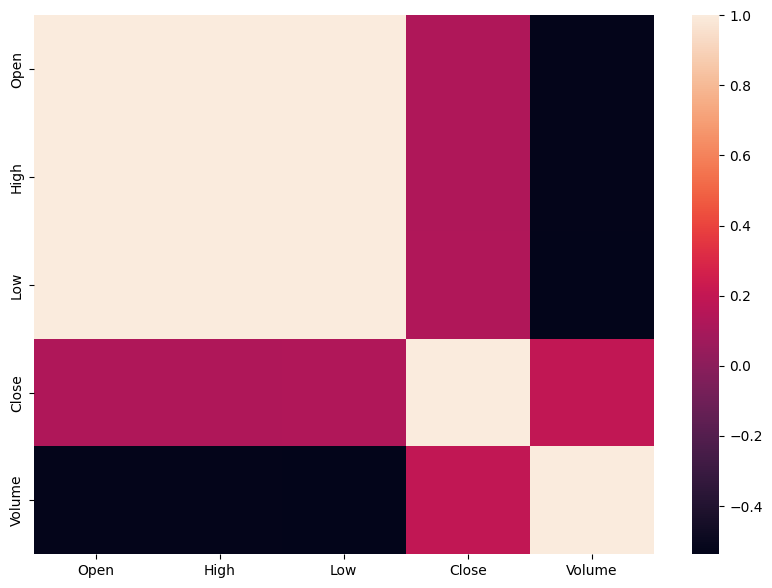

In [9]:
plt.figure(figsize=(10,7))
sns.heatmap(data.drop("Date", axis=1).corr())
plt.show()

In [10]:
scaled_data = scaled_data.drop([0, 2, 3], axis=1)
scaled_data

,1,4
0,0.096401,0.295258
1,0.098344,0.229936
2,0.092517,0.263612
3,0.088819,0.216179
4,0.076718,0.467797
...,...,...
1253,0.955292,0.024650
1254,0.964853,0.031286
1255,0.958074,0.045891
1256,0.942574,0.029491


In [11]:
def split_seq_multivariate(sequence, n_past, n_future):

    '''
    n_past ==> no of past observations
    n_future ==> no of future observations
    '''
    x = []
    y = []
    for window_start in range(len(sequence)):
        past_end = window_start + n_past
        future_end = past_end + n_future
        if future_end > len(sequence):
            break
        # slicing the past and future parts of the window (this indexing is for 2 features vala data only)
        past = sequence[window_start:past_end, :]
        future = sequence[past_end:future_end, -1]
        x.append(past)
        y.append(future)

    return np.array(x), np.array(y)

In [12]:
n_steps = 60

scaled_data = scaled_data.to_numpy()
scaled_data.shape

(1258, 2)

In [13]:
x, y = split_seq_multivariate(scaled_data, n_steps, 1)

In [14]:
x.shape, y.shape

((1198, 60, 2), (1198, 1))

In [15]:
x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2, random_state=42)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((958, 60, 2), (240, 60, 2), (958, 1), (240, 1))

In [16]:
model = Sequential()
model.add(LSTM(612, input_shape=(n_steps, 2)))
model.add(Dense(50, activation='relu'))
model.add(Dense(50, activation='relu'))
model.add(Dense(30, activation='relu'))
model.add(Dense(1))

C:\Users\princ\miniforge3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 612)                 │       1,505,520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 50)                  │          30,650 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 50)                  │           2,550 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 30)                  │           1,530 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              31 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,540,281 (5.88 MB)

 Trainable params: 1,540,281 (5.88 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [23]:
history = model.fit(
    x_train, y_train,
    epochs=25,
    validation_data=(x_test, y_test)
)

Epoch 1/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 186ms/step - loss: 0.0033 - mae: 0.0322 - val_loss: 0.0038 - val_mae: 0.0349
Epoch 2/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 183ms/step - loss: 0.0033 - mae: 0.0319 - val_loss: 0.0037 - val_mae: 0.0383
Epoch 3/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 187ms/step - loss: 0.0034 - mae: 0.0324 - val_loss: 0.0038 - val_mae: 0.0383
Epoch 4/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 159ms/step - loss: 0.0034 - mae: 0.0320 - val_loss: 0.0035 - val_mae: 0.0345
Epoch 5/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 161ms/step - loss: 0.0033 - mae: 0.0319 - val_loss: 0.0037 - val_mae: 0.0343
Epoch 6/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 167ms/step - loss: 0.0033 - mae: 0.0312 - val_loss: 0.0035 - val_mae: 0.0347
Epoch 7/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 174ms/step - loss: 0.0033 - mae: 0.0316 - val_loss: 0.0038 - val_mae: 0.0348
Epoch 8/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 173ms/step - loss: 0.0033 - mae: 0.0312 - val_loss: 0.0035 - val_mae: 0.0369
Epoch 9/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 173ms/step - lo

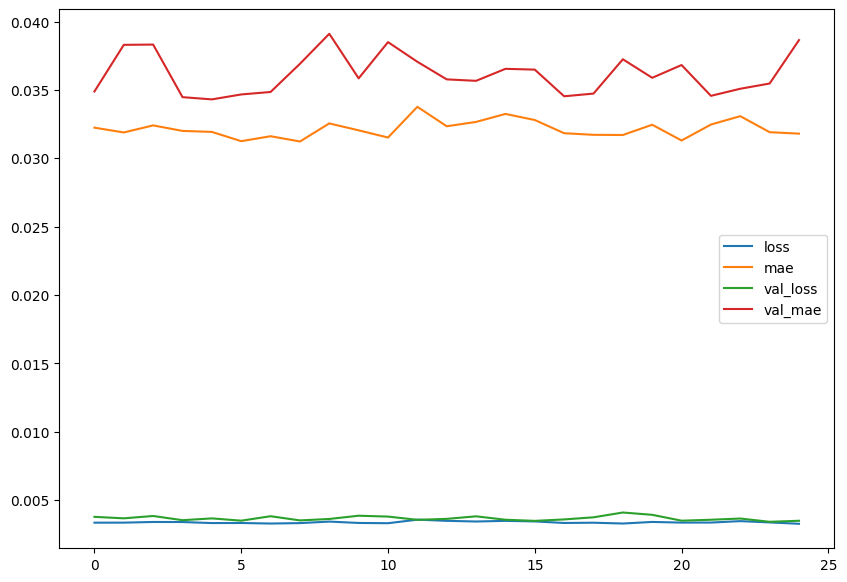

In [24]:
pd.DataFrame(history.history).plot(figsize=(10,7))
plt.show()

In [25]:
model.evaluate(x_test, y_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0035 - mae: 0.0386


[0.003485579276457429, 0.03864152729511261]

In [26]:
predictions = model.predict(x_test)
predictions.shape

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step


(240, 1)

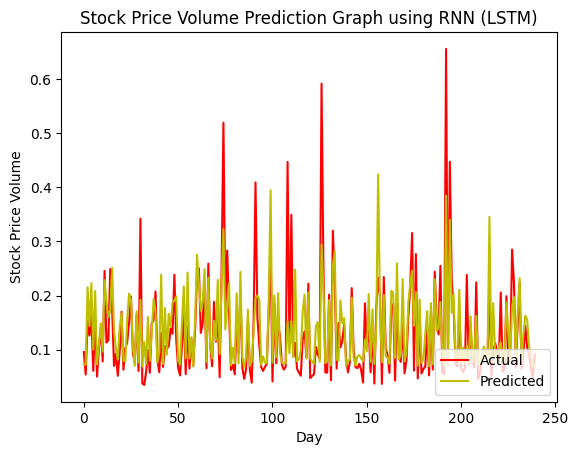

<Figure size 1000x700 with 0 Axes>

In [27]:
plt.plot(y_test, c = 'r')
plt.plot(predictions, c = 'y')
plt.xlabel('Day')
plt.ylabel('Stock Price Volume')
plt.title('Stock Price Volume Prediction Graph using RNN (LSTM)')
plt.legend(['Actual','Predicted'], loc = 'lower right')
plt.figure(figsize=(10,7))
plt.show()

In [28]:
plt.plot(real, color='red', label='Real Price')
plt.plot(predicted, color='blue', label='Predicted Price')

plt.title("Google Stock Price Prediction (RNN)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

NameError: name 'real' is not defined

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 156ms/step - loss: 0.0033 - mae: 0.0320
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 150ms/step - loss: 0.0034 - mae: 0.0323
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 139ms/step - loss: 0.0034 - mae: 0.0330
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 144ms/step - loss: 0.0033 - mae: 0.0320
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 170ms/step - loss: 0.0033 - mae: 0.0312
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 171ms/step - loss: 0.0033 - mae: 0.0319
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 157ms/step - loss: 0.0032 - mae: 0.0316
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 163ms/step - loss: 0.0033 - mae: 0.0319
Epoch 9/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 153ms/step - loss: 0.0033 - mae: 0.0316
Epoch 10/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 153ms/step - loss: 0.0033 - mae: 0.0319
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


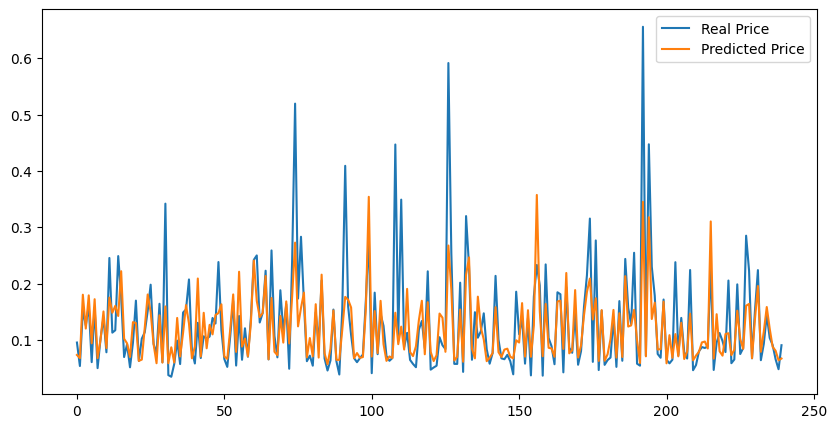

In [32]:
# =========================
# Step 1: Define scalers
# =========================
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

# =========================
# Step 2: Convert 3D → 2D for scaling
# =========================
x_train_2d = x_train.reshape(-1, x_train.shape[-1])
x_test_2d  = x_test.reshape(-1, x_test.shape[-1])

# =========================
# Step 3: Apply scaling
# =========================
x_train_2d = scaler_x.fit_transform(x_train_2d)
x_test_2d  = scaler_x.transform(x_test_2d)

y_train = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_test  = scaler_y.transform(y_test.reshape(-1, 1))

# =========================
# Step 4: Convert back to 3D
# =========================
x_train = x_train_2d.reshape(x_train.shape[0], x_train.shape[1], x_train.shape[2])
x_test  = x_test_2d.reshape(x_test.shape[0], x_test.shape[1], x_test.shape[2])

# =========================
# Step 5: Train
# =========================
history = model.fit(x_train, y_train, epochs=10)

# =========================
# Step 6: Predict
# =========================
predicted = model.predict(x_test)

# =========================
# Step 7: Inverse transform
# =========================
predicted = scaler_y.inverse_transform(predicted)
real = scaler_y.inverse_transform(y_test)

# =========================
# Step 8: Plot
# =========================
plt.figure(figsize=(10,5))
plt.plot(real, label="Real Price")
plt.plot(predicted, label="Predicted Price")
plt.legend()
plt.show()